# Fig. 6K-L — Neighborhood Enrichment & Co-occurrence, pt02 Senescent-High Hepatocytes (MASH, Stage 4)

**Purpose:** Using the `celltype_proj_heps_pt02` labels from
`250303_01_module_score_top50_deseq2_fc_hep_sen.ipynb` (score > 0.02 =
`Hepatocytes.Senescent.High`, on the tangram run trained on stage 3+4
high-fibrosis donors only), run Squidpy neighborhood enrichment and
co-occurrence analysis to see how senescent/high-score hepatocytes are
spatially distributed relative to other cell types.

**Sample:** `HL20221019_broad_no_mast_filt` (MASH, stage 4).
**Note:** requires a high-memory node (~500 GB) — resorting all barcodes on
the full object is memory-heavy. `Hepatocytes.Senescent` is the MASH-associated
label; `Hepatocytes.Senescent.High` are the subset scoring above the pt02
cutoff.

**Pipeline:** load the full tangram-predicted object and the pt02-labeled
hepatocyte object, map the hepatocyte labels onto the full object, run
`spatial_neighbors` + `nhood_enrichment`, then `co_occurrence` per cell type
(co-occurrence takes ~1h50m on this subset), saving figures throughout.

**Cleanup notes (this pass):** removed duplicate re-runs of the same
label-mapping code and several bare variable-display debugging cells,
converted a plain-text note that had been pasted directly into a code cell
(causing a `SyntaxError`) into a markdown note instead, removed an unused
color-palette dict and an unused/superseded colormap definition, and
consolidated scattered duplicate imports (including two never actually used
in this notebook: `pandas` and `anndata`).

In [1]:
import os
import datetime

import scanpy as sc
import squidpy as sq
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


Plotting spatial zones from the tangram run trained only on stage-3/4 high-fibrosis donors. `Hepatocytes.Senescent.High` cells are those with a module score > 0.02 for Weston's high-fibrosis-vs-control DEGs on the senescent cluster (see `250303_01_module_score_top50_deseq2_fc_hep_sen.ipynb`).

In [3]:
adata = sc.read_h5ad('/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/misc/tangram_scores_dist2/HL20221019_broad_no_mast_filt/adata_0.5_tangram_filt.h5ad')

In [4]:
adata

AnnData object with n_obs × n_vars = 270311 × 17931
    obs: 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'clusters', 'uniform_density', 'rna_count_based_density', 'celltype_proj', 'pred_cell_types'
    uns: 'celltype_proj_colors', 'clusters', 'hvg', 'neighbors', 'pca', 'spatial', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial_cropped', 'tangram_ct_pred'

In [5]:
adata.obs['pred_cell_types'].value_counts()

pred_cell_types
Hepatocytes      178400
Myeloid           22435
Endothelial       21097
HSC               17476
Cholangiocyte     10859
B                 10049
T_NK               9995
Name: count, dtype: int64

In [6]:
adata_heps = sc.read_h5ad('/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/neighborhood_analysis/high_score_sen_cells/adata_heps_score_sencells_labels.h5ad')

In [8]:
# cell proporition when training high fib
adata_heps.obs['celltype_proj_heps_pt02'].value_counts()

celltype_proj_heps_pt02
Hepatocytes.Zone2             86149
Hepatocytes.Zone3             32992
Hepatocytes.Senescent         30487
Hepatocytes.Zone1             26904
Hepatocytes.Senescent.High     1868
Name: count, dtype: int64

Sanity-check fractions of high-scoring senescent hepatocytes:

In [1]:
1868/30487 #percentage of >0.02 scoring cells out of all tangram-called Hepatocytes.Senescent hepatocytes

0.061272017581264146

In [ ]:
30487

In [2]:
1868/178400 #percentage of >0.02 out of all tangram-called hepatocytes

0.01047085201793722

In [3]:
1868/270311 # percentage out of total cells in NASH liver

0.006910558578822171

In [11]:
adata_heps.obs['pred_cell_types'].value_counts()

pred_cell_types
Hepatocytes    178400
Name: count, dtype: int64

## Map pt02 hepatocyte labels onto the full spatial object

In [12]:
full_adata = adata.copy()

In [13]:
hepatocyte_mapping = adata_heps.obs['celltype_proj_heps_pt02'].to_dict()
full_adata.obs['celltype_proj_heps_pt02'] = full_adata.obs.index.map(hepatocyte_mapping)

full_adata.obs['celltype_proj_heps_pt02'] = full_adata.obs['celltype_proj_heps_pt02'].astype(str)
full_adata.obs['pred_cell_types'] = full_adata.obs['pred_cell_types'].astype(str)
full_adata.obs['celltype_proj_heps_pt02'] = full_adata.obs['celltype_proj_heps_pt02'].fillna(
    full_adata.obs['pred_cell_types']
)
full_adata.obs['celltype_proj_heps_pt02'] = full_adata.obs['celltype_proj_heps_pt02'].astype("category")

print(full_adata.obs[['pred_cell_types', 'celltype_proj_heps_pt02']].head())


       pred_cell_types celltype_proj_heps_pt02
505995     Hepatocytes       Hepatocytes.Zone2
505996     Hepatocytes       Hepatocytes.Zone3
505997               B                     nan
506002     Hepatocytes       Hepatocytes.Zone2
506003     Endothelial                     nan


/tmp/ipykernel_1390471/683075251.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  full_adata.obs['celltype_proj_heps_pt02'].fillna(full_adata.obs['pred_cell_types'], inplace=True)


In [17]:
full_adata.obs['celltype_proj_heps_pt02'].value_counts()

celltype_proj_heps_pt02
Hepatocytes.Zone2             86149
Hepatocytes.Zone3             32992
Hepatocytes.Senescent         30487
Hepatocytes.Zone1             26904
Myeloid                       22435
Endothelial                   21097
HSC                           17476
Cholangiocyte                 10859
B                             10049
T_NK                           9995
Hepatocytes.Senescent.High     1868
Name: count, dtype: int64

In [18]:
adata = full_adata.copy()


## Output directories

In [19]:
os.makedirs('/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/neighborhood_analysis/', exist_ok = True)

In [20]:
os.makedirs('/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/neighborhood_analysis/high_score_sen_cells_pt02/', exist_ok = True)

In [21]:
outdir = '/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/neighborhood_analysis/high_score_sen_cells_pt02/'

## Neighborhood enrichment

Cell types compared:
- TREM2+ Macrophages, Macrophages, Activated and quiescent HSCs, Hepatocytes
- MASH-associated hepatocytes (`Hepatocytes.Senescent` label)
- Senescent MASH-associated hepatocytes (p16-positive by the pt02 cutoff, `Hepatocytes.Senescent.High`)

In [22]:
adata_sub = adata.copy()


In [25]:
celltype_counts = adata_sub.obs['celltype_proj_heps_pt02'].value_counts()
celltype_counts

celltype_proj_heps_pt02
Hepatocytes.Zone2             86149
Hepatocytes.Zone3             32992
Hepatocytes.Senescent         30487
Hepatocytes.Zone1             26904
Myeloid                       22435
Endothelial                   21097
HSC                           17476
Cholangiocyte                 10859
B                             10049
T_NK                           9995
Hepatocytes.Senescent.High     1868
Name: count, dtype: int64

In [26]:
adata_sub.obs['celltype_proj_heps_pt02_cp'] = adata_sub.obs['celltype_proj_heps_pt02']
# If we run nhood_enrichment directly on celltype_proj_heps_pt02 (a category
# dtype carrying stale/unused categories from earlier subsetting), squidpy
# raises: "There are 10 color bins including extensions, but ncolors = 7;
# ncolors must equal or exceed the number of bins". A plain re-copy as above
# refreshes the category list to just what's actually present.


2025-03-03 14:10:47.846200
2025-03-03 14:11:01.726780


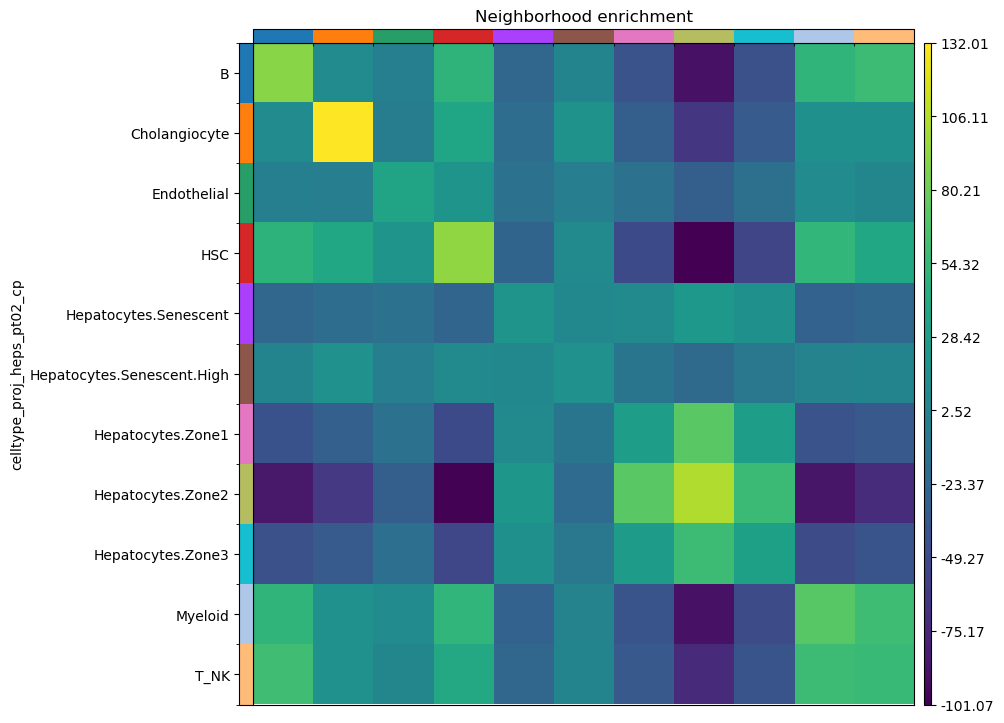

In [27]:
print(datetime.datetime.now())

sq.gr.spatial_neighbors(adata_sub)
sq.gr.nhood_enrichment(adata_sub, cluster_key="celltype_proj_heps_pt02_cp", show_progress_bar  = False) #with high fibrosis donors for tangram
sq.pl.nhood_enrichment(adata_sub, cluster_key="celltype_proj_heps_pt02_cp")
print(datetime.datetime.now())


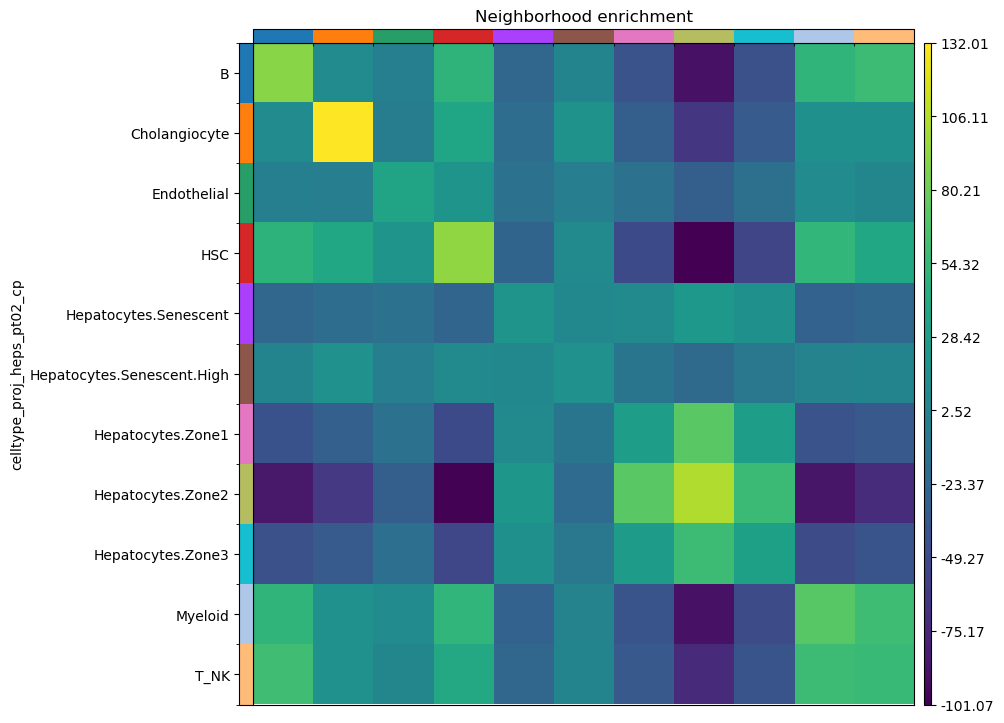

In [28]:
sq.pl.nhood_enrichment(adata_sub, cluster_key="celltype_proj_heps_pt02_cp") #with match sen
plt.savefig(outdir + 'enrich_mat_sub.pdf', bbox_inches='tight')


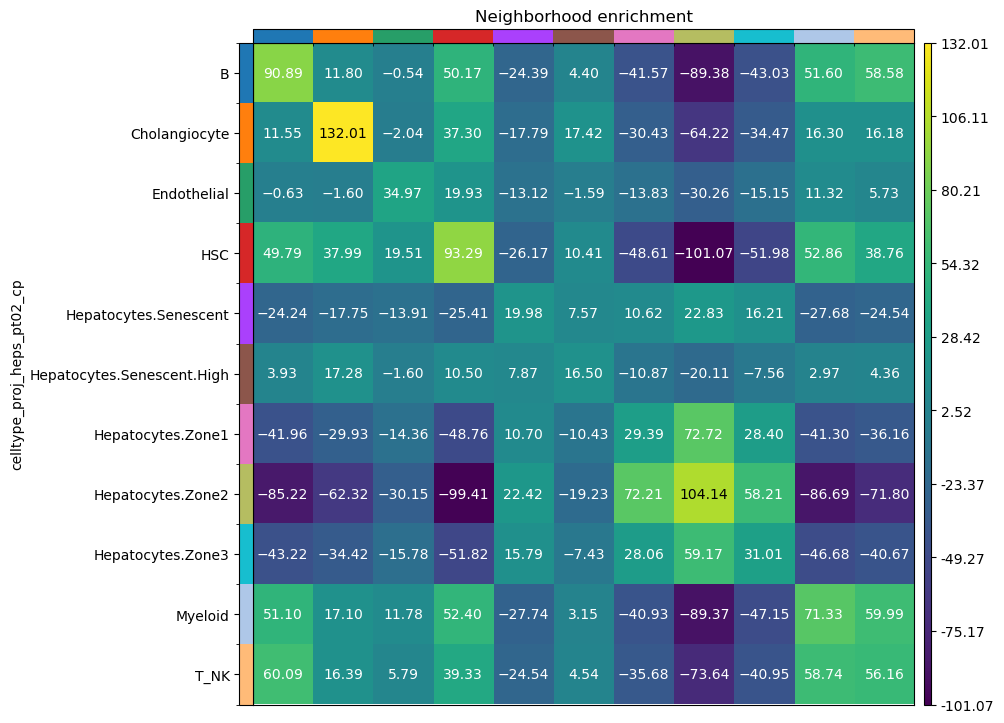

In [29]:
sq.pl.nhood_enrichment(adata_sub, cluster_key="celltype_proj_heps_pt02_cp", annotate = True)
plt.savefig(outdir + 'enrich_mat_sub_anno.pdf', bbox_inches='tight')


Observation: quiescent HSCs seem to co-occur less often near activated HSCs than expected (~52.74%); the reverse (activated near quiescent) is a bit more common (~77.30%).

## Co-occurrence analysis

`sq.gr.co_occurrence` takes roughly 1h50m to run on this subset (squidpy prints a progress bar that can look idle even while it's running).

In [30]:
# Convert unique values in the 'celltype' column to a list
celltypes = adata_sub.obs['celltype_proj_heps_pt02_cp'].unique().tolist()
print(celltypes)

['Hepatocytes.Zone2', 'Hepatocytes.Zone3', 'B', 'Endothelial', 'Myeloid', 'Cholangiocyte', 'HSC', 'T_NK', 'Hepatocytes.Senescent.High', 'Hepatocytes.Senescent', 'Hepatocytes.Zone1']


In [31]:
print(datetime.datetime.now())
sq.gr.co_occurrence(adata_sub, cluster_key="celltype_proj_heps_pt02_cp", show_progress_bar = False) 
#  | 0/7140 [00:00<?, ?/s]
# WARNING: `n_splits` was automatically set to `119` to prevent `242504x242504` distance matrix from being created
print(datetime.datetime.now())

2025-03-03 14:13:11.784023
2025-03-03 16:09:08.457181


Hepatocytes.Zone2
ERROR: Unable to fetch palette, reason: 'celltype_proj_heps_pt02_cp_colors'. Using `None`.
Hepatocytes.Zone3
ERROR: Unable to fetch palette, reason: 'celltype_proj_heps_pt02_cp_colors'. Using `None`.
B
ERROR: Unable to fetch palette, reason: 'celltype_proj_heps_pt02_cp_colors'. Using `None`.
Endothelial
ERROR: Unable to fetch palette, reason: 'celltype_proj_heps_pt02_cp_colors'. Using `None`.
Myeloid
ERROR: Unable to fetch palette, reason: 'celltype_proj_heps_pt02_cp_colors'. Using `None`.
Cholangiocyte
ERROR: Unable to fetch palette, reason: 'celltype_proj_heps_pt02_cp_colors'. Using `None`.
HSC
ERROR: Unable to fetch palette, reason: 'celltype_proj_heps_pt02_cp_colors'. Using `None`.
T_NK
ERROR: Unable to fetch palette, reason: 'celltype_proj_heps_pt02_cp_colors'. Using `None`.
Hepatocytes.Senescent.High
ERROR: Unable to fetch palette, reason: 'celltype_proj_heps_pt02_cp_colors'. Using `None`.
Hepatocytes.Senescent
ERROR: Unable to fetch palette, reason: 'celltype_p

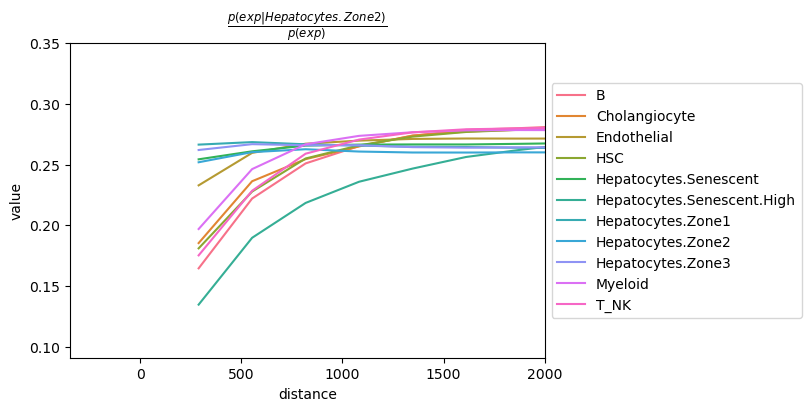

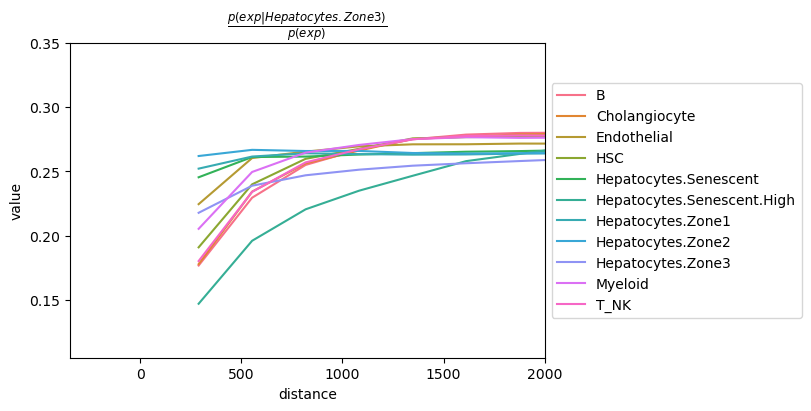

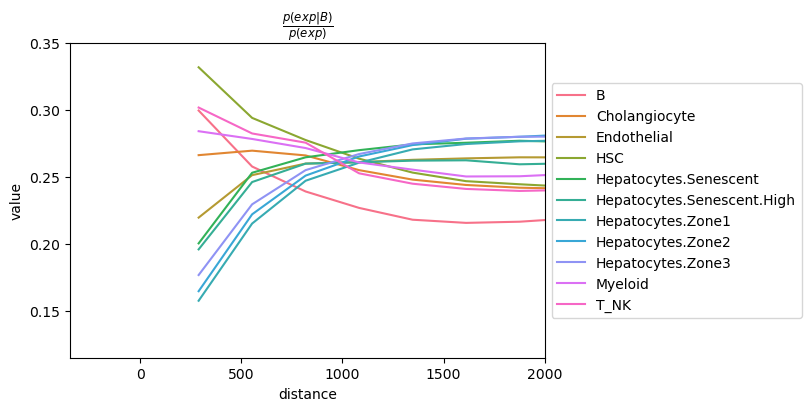

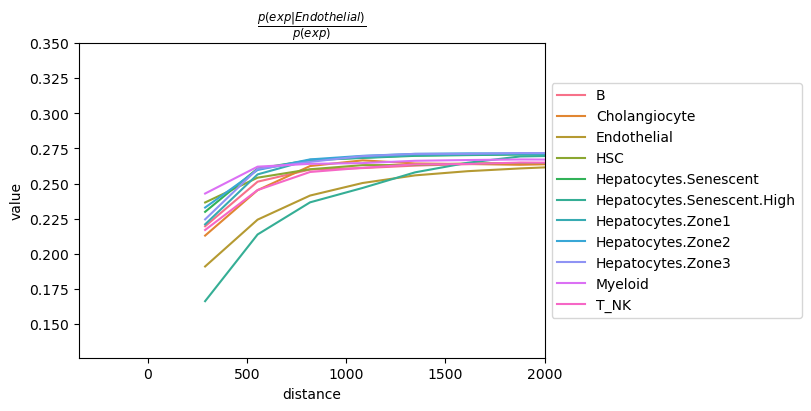

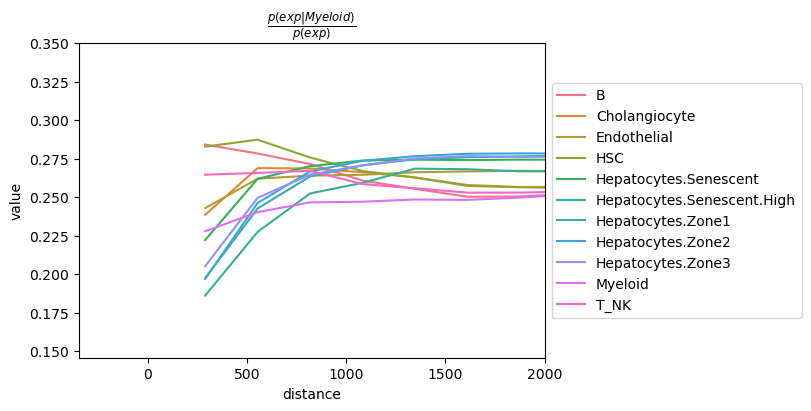

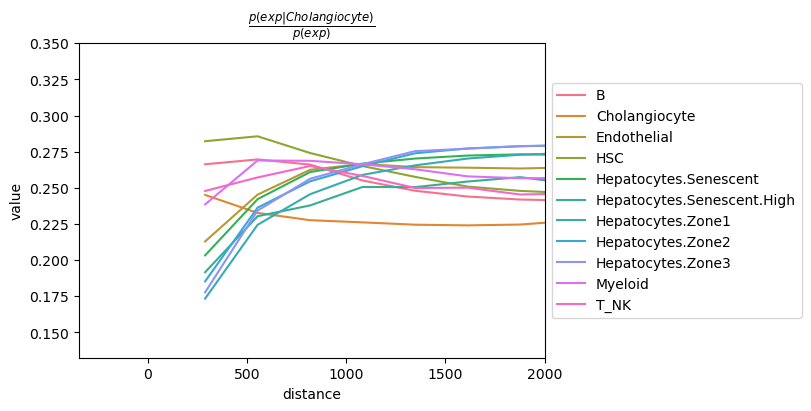

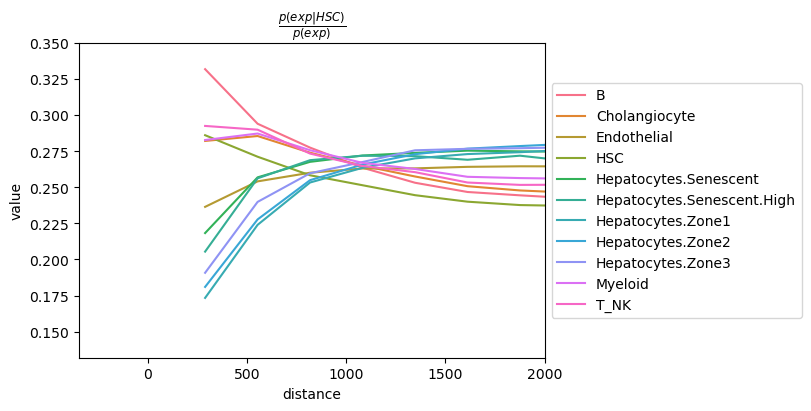

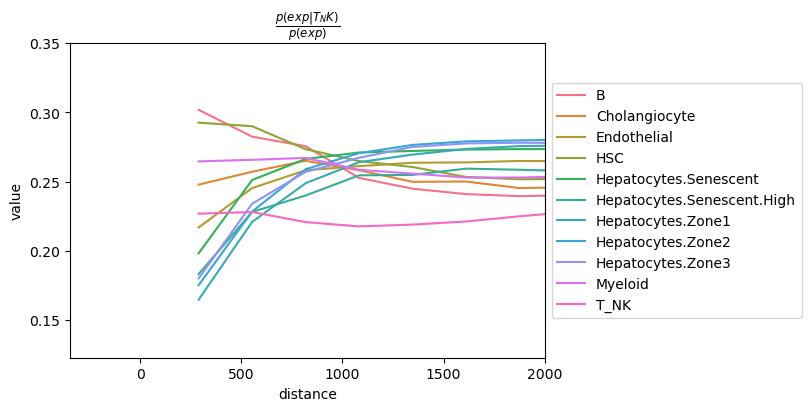

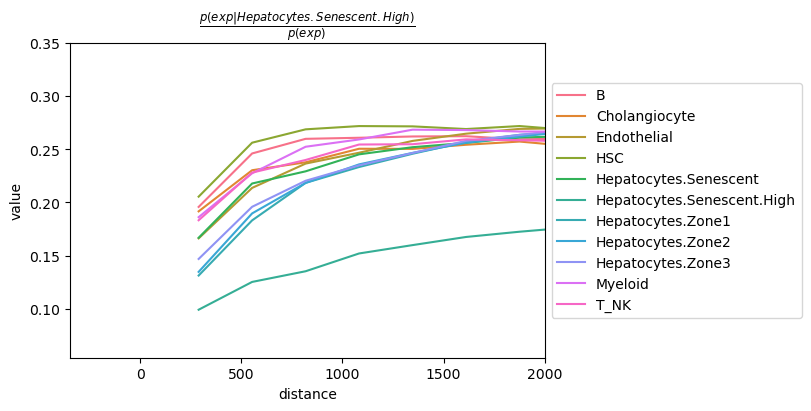

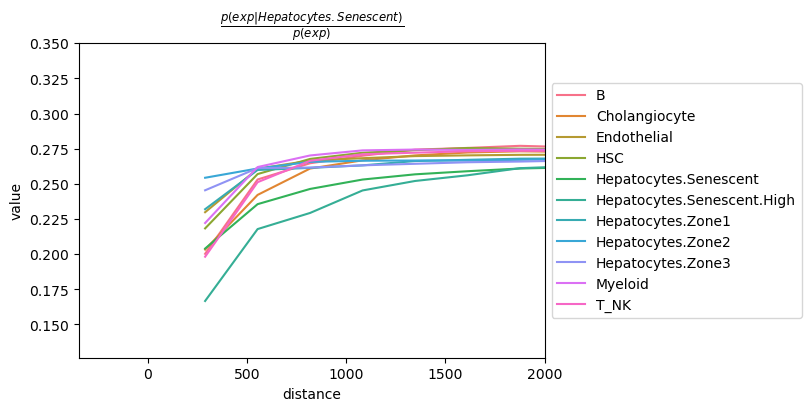

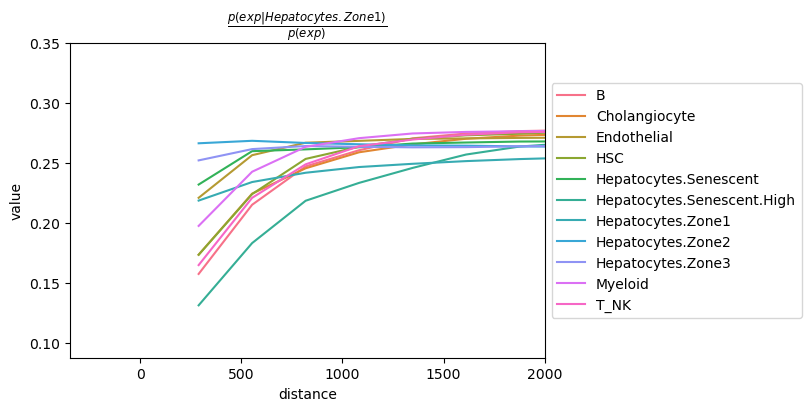

In [33]:
for ct in celltypes:
    print(ct)
    sq.pl.co_occurrence(
        adata_sub,
        cluster_key="celltype_proj_heps_pt02_cp",
        clusters=ct,
        figsize=(8, 4),
    )
    
    plt.xlim(right=2000)
    plt.ylim(top=0.35)

    #plt.ylim(top=0.7)
    
    plt.savefig(outdir + ct + '.pdf')


## Save the neighbor-graph object and reload it

In [39]:
adata_sub.write_h5ad('/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/neighborhood_analysis/high_score_sen_cells_pt02/adata_zones_broad_celltypes_zones_highsen_pt02_neighbor.h5ad')

In [5]:
adata_pt02 = sc.read_h5ad('/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/neighborhood_analysis/high_score_sen_cells_pt02/adata_zones_broad_celltypes_zones_highsen_pt02_neighbor.h5ad')

In [6]:
# Convert unique values in the 'celltype' column to a list
celltypes = adata_pt02.obs['celltype_proj_heps_pt02'].unique().tolist()
print(celltypes)

['Hepatocytes.Zone2', 'Hepatocytes.Zone3', 'B', 'Endothelial', 'Myeloid', 'Cholangiocyte', 'HSC', 'T_NK', 'Hepatocytes.Senescent.High', 'Hepatocytes.Senescent', 'Hepatocytes.Zone1']


## Re-plot co-occurrence with a custom neon color palette

In [25]:
neon_palette = {
    "Hepatocytes.Zone2": "#00BFFF",          # Neon Deep Sky Blue
    "Hepatocytes.Zone3": "#FFD700",          # Neon Gold Yellow
    "Hepatocytes.Senescent": "#FF4500",      # Neon Orange-Red
    "Hepatocytes.Zone1": "#FF1493",          # Neon Deep Pink
    "Myeloid": "#0000FF",                    # Neon Blue
    "Endothelial": "#8A2BE2",                # Neon Purple
    "HSC": "#00FFFF",                        # Neon Cyan
    "Cholangiocyte": "#00FF00",              # Neon Green
    "B": "#FF8800",                          # Neon Orange
    "T_NK": "#FFFA00",                       # Neon Yellow
    "Hepatocytes.Senescent.High": "#FF007F", # Neon Pink
}
neon_cmap = mcolors.ListedColormap(list(neon_palette.values()), name="neon_cmap")


Hepatocytes.Zone2
Hepatocytes.Zone3
B
Endothelial
Myeloid
Cholangiocyte
HSC
T_NK
Hepatocytes.Senescent.High
Hepatocytes.Senescent
Hepatocytes.Zone1


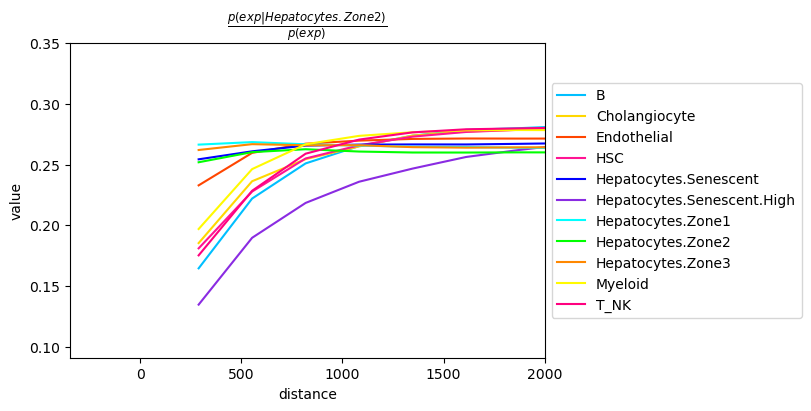

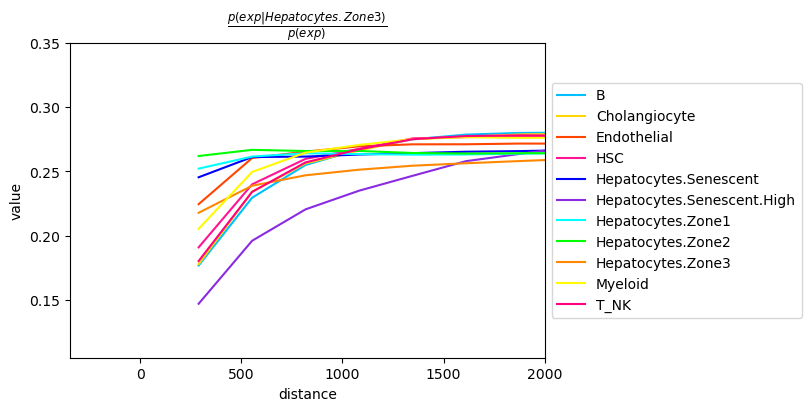

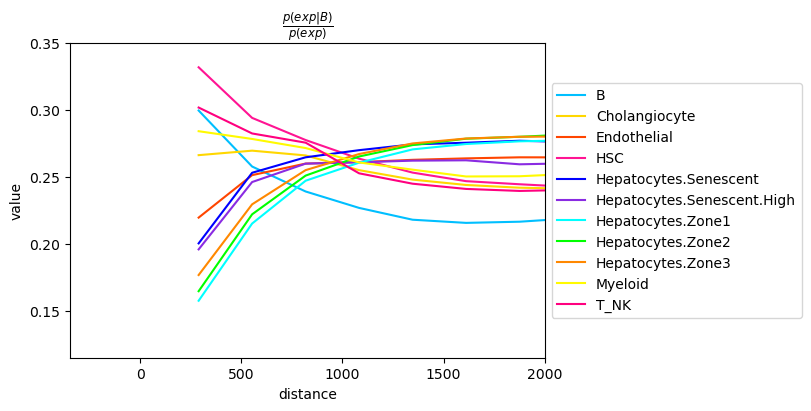

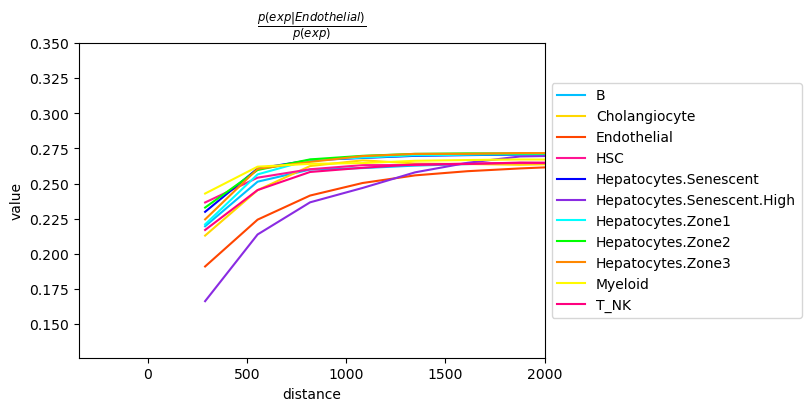

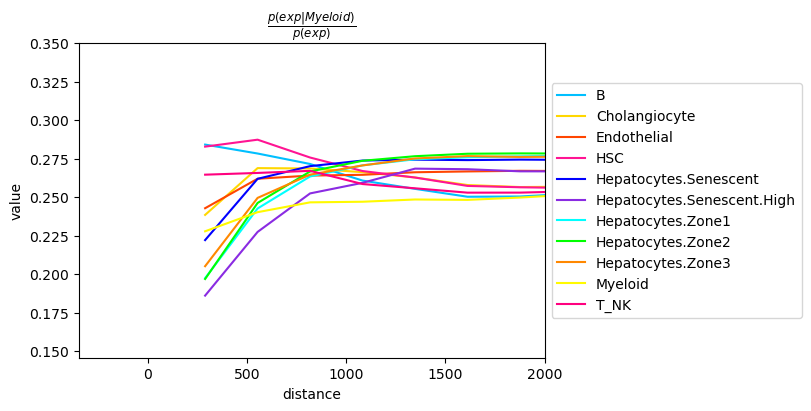

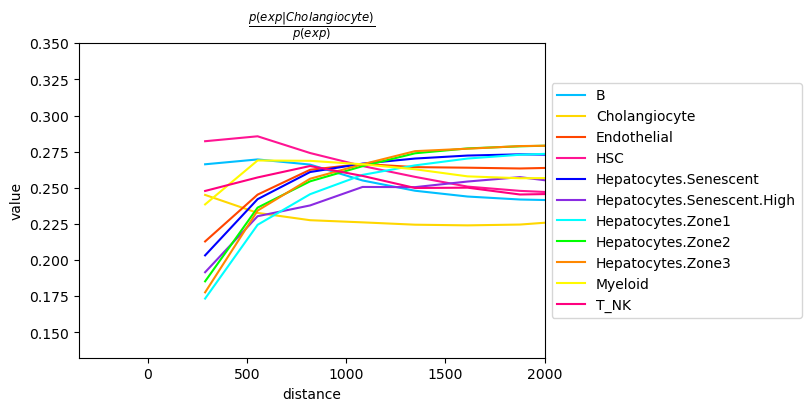

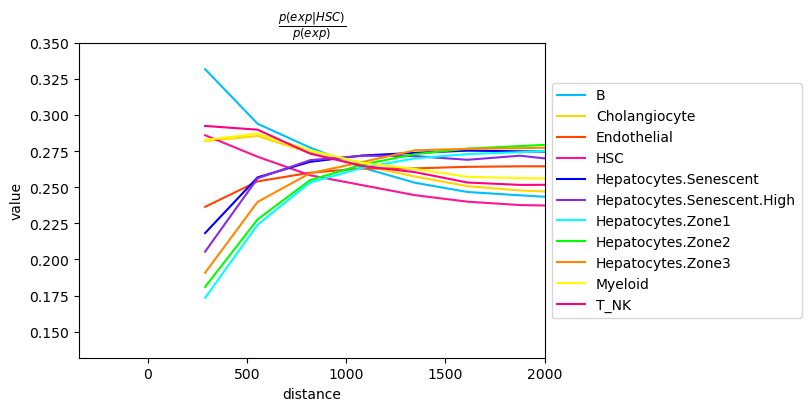

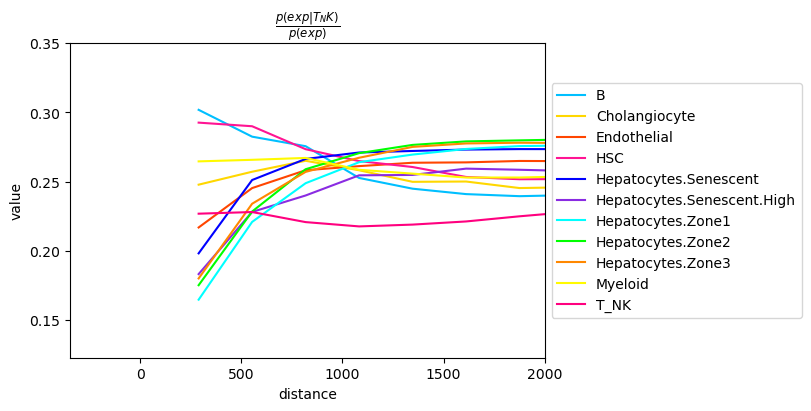

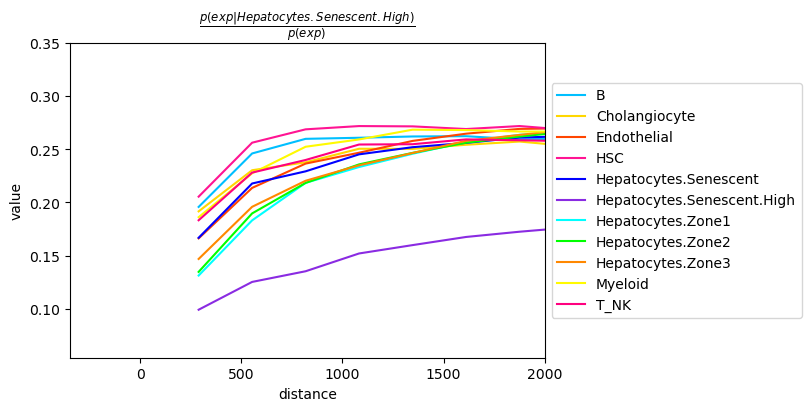

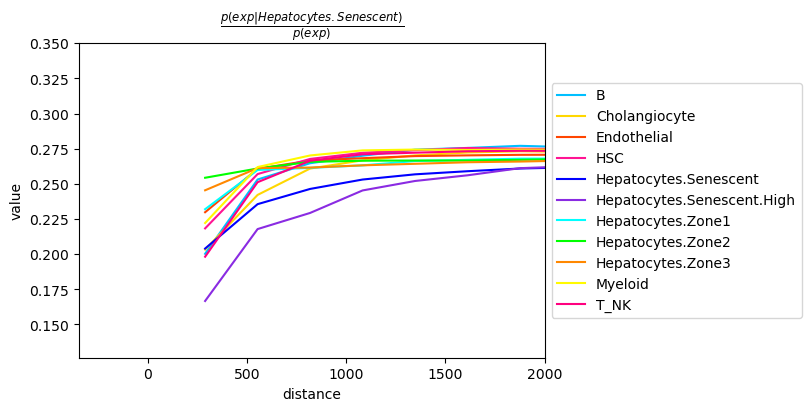

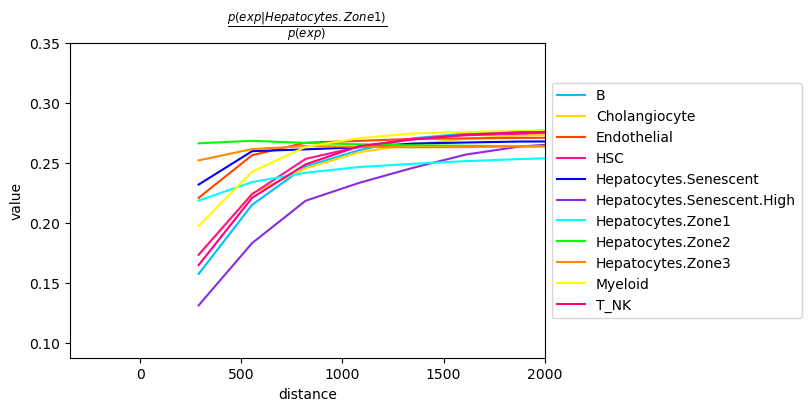

In [26]:
for ct in celltypes:
    print(ct)
    sq.pl.co_occurrence(
        adata_pt02,
        cluster_key="celltype_proj_heps_pt02_cp",
        palette = neon_cmap,
        clusters=ct,
        figsize=(8, 4),
    )
    
    plt.xlim(right=2000)
    plt.ylim(top=0.35)

    #plt.ylim(top=0.7)
    
    plt.savefig(outdir + ct + '.pdf')


In [38]:
adata_pt02.obs['celltype_proj_heps_pt02'].value_counts()

celltype_proj_heps_pt02
Hepatocytes.Zone2             86149
Hepatocytes.Zone3             32992
Hepatocytes.Senescent         30487
Hepatocytes.Zone1             26904
Myeloid                       22435
Endothelial                   21097
HSC                           17476
Cholangiocyte                 10859
B                             10049
T_NK                           9995
Hepatocytes.Senescent.High     1868
Name: count, dtype: int64

## Alias the hepatocyte-zone/subtype column for downstream use

In [ ]:
adata_sub.obs['celltype_hep_zones'] = adata_sub.obs['celltype_proj_heps_pt02']


In [43]:
adata_sub.obs['celltype_hep_zones'].value_counts()

celltype_hep_zones
Hepatocytes.Zone2        86149
Hepatocytes.Zone3        32992
Hepatocytes.Senescent    32355
Hepatocytes.Zone1        26904
Myeloid                  22435
Endothelial              21097
HSC                      17476
Cholangiocyte            10859
B                        10049
T_NK                      9995
Name: count, dtype: int64